In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [2]:
data = pd.read_csv("online_retail_II.csv")


In [3]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [5]:
data.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [6]:
data.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(34335)

Data cleaning

In [8]:
data.dropna(subset=['Customer ID'], inplace=True) #drop rows with no customer ID

In [9]:
data.drop_duplicates(inplace=True)

In [10]:
#drop the rows where invoice starts with 'C' (cancelled invoices)
cancelled = data[data['Invoice'].str.startswith('C')].index
data.drop(index=cancelled, inplace=True)

In [11]:
data = data[(data['Quantity'] > 0) & (data['Price'] >0)] #only keep the columns where quantity and price values are more than 0 , other values are outliers

In [12]:
#fix datatypes
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
data['Customer ID'] = data["Customer ID"].astype(int)

In [13]:
data.shape #rows and cols

(779425, 8)

In [14]:
data.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Feature engineering (currently, there are multiple rows per customer (one row per item bought)

In [15]:
data["TotalSpend"] = data["Quantity"] * data["Price"]

In [16]:
reference_date = data["InvoiceDate"].max() + pd.Timedelta(days=1) #most recent invoicing date and adds 1 day to it
# .Timedelta() is just a way to represent a duration of time in pandas

In [17]:
#RFM framework -> recency frequency monetary -> an industry standard in retail analytics
rfm = data.groupby("Customer ID").agg( #aggregates multiple rows into one
    Recency = ("InvoiceDate", lambda x: (reference_date - x.max()).days), #how many days since a customer last bought
    Frequency = ("Invoice", "nunique"), #how many seperate orders they placed
    Monetary = ("TotalSpend", "sum"), # how much money they spent in total
).reset_index()

x.max() → finds a customer's most recent purchase date → 2011-12-01

reference_date - x.max() → subtracts → gives a Timedelta like 8 days

.days → extracts just the number → 8

So Recency for this customer = 8 days since last purchase.

lambda x : () -> a mini function that returns (reference_date - x.max()).days), x is the input parameter

nunique = count of unique values

In [18]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [23]:
pd.DataFrame(scaled_data, columns=['Recency', 'Frequency', 'Monetary']).head() #scaled_data is a numpy array and not a dataframe so we convert into into one to view head

,Recency,Frequency,Monetary
0,0.595584,0.438998,5.166378
1,-0.952279,0.131502,0.136127
2,-0.603532,-0.099120,-0.064857
3,-0.871064,-0.175994,0.101996
4,0.519146,-0.406616,-0.181549


In [24]:
from sklearn.cluster import KMeans,DBSCAN
inertia = []
k_range = range(1,11)
for k in k_range:
    k_means_model = KMeans(n_clusters=k, random_state=42)
    k_means_model.fit(scaled_data)
    inertia.append(k_means_model.inertia_)

In [25]:
inertia

[17634.000000000015,
 12532.272990130685,
 7130.837844152662,
 5158.557440936724,
 3901.5309292230204,
 3295.384706235659,
 2954.951841430491,
 2681.7991266851914,
 2273.3460065321733,
 1859.9523669731088]

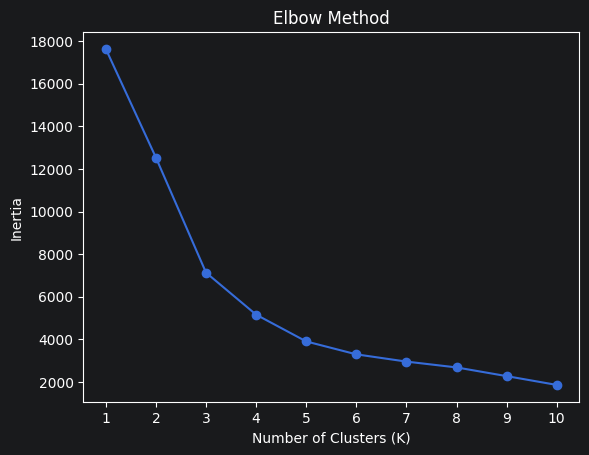

In [26]:
plt.plot(k_range, inertia, marker='o') #see the elbow curve
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.show()

In [27]:
#we move with k = 3
k_means_final = KMeans(n_clusters=3, random_state=42)
cluster_labels = k_means_final.fit_predict(scaled_data) #label our clusters


In [28]:
rfm["clusters"] = cluster_labels

In [29]:
rfm.groupby("clusters")[["Recency", "Frequency", "Monetary"]].mean() #mean value of each cluster (easier to categorize clusters seeing the mean table)

,Recency,Frequency,Monetary
clusters,,,
0,461.784577,2.212438,748.384713
1,66.233489,7.637806,3136.201806
2,23.090909,143.045455,173123.584091


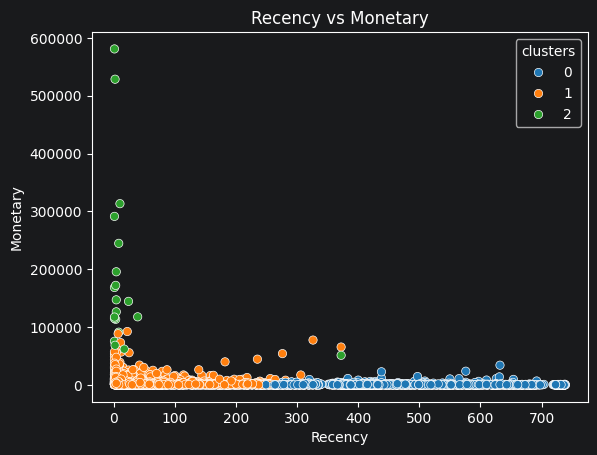

In [31]:
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='clusters', palette='tab10')
plt.title('Recency vs Monetary')
plt.show()


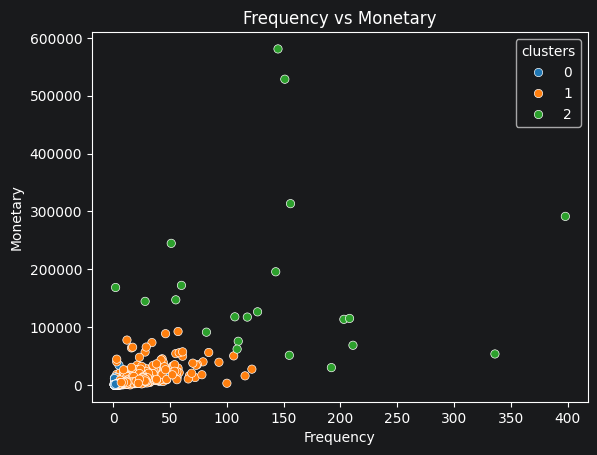

In [32]:
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='clusters', palette='tab10')
plt.title('Frequency vs Monetary')
plt.show()

In [36]:
dbscan = DBSCAN(eps=0.3, min_samples=3)
dbscan_labels = dbscan.fit_predict(scaled_data)

In [37]:
rfm["DBScan_clusters"] = dbscan_labels


In [38]:
rfm.groupby("DBScan_clusters")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
DBScan_clusters,,,
-1,109.457831,68.554217,69072.137265
0,202.825243,5.269244,1938.387191
1,56.333333,4.666667,16297.790000
2,7.142857,54.142857,20856.684286
3,605.200000,1.800000,11134.720000
4,7.000000,56.000000,11689.596667
5,141.000000,34.666667,16130.623333
6,2.666667,53.000000,33381.146667
7,250.333333,17.666667,9010.566667


Kmeans provided cleaner clusters, so we go with kmeans

In [39]:
"""Kmeans cluster 0 = very irregular and rather rare customers
cluster 1 = fairly regular
cluster 2 = VIP customers , high spenders"""
def get_marketing_strategy(cluster_id):
    if cluster_id == 0:
        return "We miss you! Here's a 25% off coupon to come back"
    elif cluster_id == 1:
        return "Thank You for being Loyal! You get Early access to new arrivals"
    elif cluster_id == 2:
        return "VIP treatment — dedicated account manager + bulk discount"


In [43]:
strategies = []
for cluster_id in rfm["clusters"]:
    strategies.append(get_marketing_strategy(cluster_id))
rfm["strategy"] = strategies

In [44]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,clusters,DBScan_clusters,strategy
0,12346,326,12,77556.46,1,-1,Thank You for being Loyal! You get Early acces...
1,12347,2,8,4921.53,1,0,Thank You for being Loyal! You get Early acces...
2,12348,75,5,2019.40,1,0,Thank You for being Loyal! You get Early acces...
3,12349,19,4,4428.69,1,0,Thank You for being Loyal! You get Early acces...
4,12350,310,1,334.40,0,0,We miss you! Here's a 25% off coupon to come back


In [45]:
import joblib
joblib.dump(k_means_final, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']